# NZ Motor Vehicle Register — Data Analysis

End-to-end analysis of the NZTA open fleet dataset using the project's `DataCleaner` and `DataAnalyzer` pipeline.


## 1. Import Required Libraries


In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from src.data_analyzer import DataAnalyzer
from src.data_cleaner import DataCleaner, load_schema
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("Libraries loaded.")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

Libraries loaded.
pandas 3.0.1  |  numpy 2.4.2


## 2. Load and Clean the Dataset

Load the metadata schema from `MVROpenData-Dictionary.csv`, then load all per-year storage CSVs, apply cleaning, and deduplicate.  
Set `years` to a list of ints (e.g. `[2020, 2021, 2022]`) to load only specific years.


In [ ]:
import logging
logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s %(name)s: %(message)s")

DICT_CSV = PROJECT_ROOT / "data" / "MVROpenData-Dictionary.csv"
STORAGE_DIR = PROJECT_ROOT / "data" / "nz" / "storage"

schema = load_schema(DICT_CSV)
print(f"Schema loaded: {len(schema)} fields")

years = None
include_pre1990 = True

cleaner = DataCleaner(STORAGE_DIR)
raw_df = cleaner.load_years(years=years, include_pre1990=include_pre1990)

print(f"\nRaw dataset:  {len(raw_df):>10,} rows × {raw_df.shape[1]} columns")

INFO src.data_cleaner: Loading VehicleYear-Pre1990.csv


Schema loaded: 38 fields


INFO src.data_cleaner: Loading VehicleYear-1990.csv
INFO src.data_cleaner: Loading VehicleYear-1991.csv
INFO src.data_cleaner: Loading VehicleYear-1992.csv
INFO src.data_cleaner: Loading VehicleYear-1993.csv
INFO src.data_cleaner: Loading VehicleYear-1994.csv
INFO src.data_cleaner: Loading VehicleYear-1995.csv
INFO src.data_cleaner: Loading VehicleYear-1996.csv
INFO src.data_cleaner: Loading VehicleYear-1997.csv
INFO src.data_cleaner: Loading VehicleYear-1998.csv
INFO src.data_cleaner: Loading VehicleYear-1999.csv
INFO src.data_cleaner: Loading VehicleYear-2000.csv
INFO src.data_cleaner: Loading VehicleYear-2001.csv
INFO src.data_cleaner: Loading VehicleYear-2002.csv
INFO src.data_cleaner: Loading VehicleYear-2003.csv
INFO src.data_cleaner: Loading VehicleYear-2004.csv
INFO src.data_cleaner: Loading VehicleYear-2005.csv
INFO src.data_cleaner: Loading VehicleYear-2006.csv
INFO src.data_cleaner: Loading VehicleYear-2007.csv
INFO src.data_cleaner: Loading VehicleYear-2008.csv
INFO src.dat


Raw dataset:   5,837,680 rows × 38 columns


## 3. Data Cleaning and Preprocessing

Apply type coercions, categorical validation, strip whitespace, and remove exact duplicate rows.


In [6]:
df, quality_df = cleaner.clean(raw_df, schema)
df, n_dupes = DataCleaner.drop_duplicates(df)

print(f"Cleaned dataset: {len(df):>10,} rows × {df.shape[1]} columns")
print(f"Exact duplicates removed: {n_dupes:,}")

INFO src.data_cleaner: Cleaning complete. 38 columns processed.
INFO src.data_cleaner: Removed 52358 exact duplicate rows


Cleaned dataset:  5,785,322 rows × 38 columns
Exact duplicates removed: 52,358


In [7]:
quality_df.sort_values("null_rate_pct", ascending=False).reset_index(drop=True)

,column,dtype_schema,dtype_pandas,total_rows,null_count,null_rate_pct,coercion_nulls_added,invalid_categorical_count
0,ALTERNATIVE_MOTIVE_POWER,Text (Categorical),category,5837680,5831027,99.89,0,0
1,ROAD_TRANSPORT_CODE,Text (Categorical),category,5837680,5740237,98.33,0,0
2,FC_EXTRA_URBAN,Decimal,float64,5837680,4578147,78.42,0,0
3,FC_URBAN,Decimal,float64,5837680,4496270,77.02,0,0
4,INDUSTRY_MODEL_CODE,Text (Free),str,5837680,4041159,69.23,0,0
5,CHASSIS7,Text (Free),str,5837680,3412957,58.46,0,0
6,TRANSMISSION_TYPE,Text (Categorical),category,5837680,3350212,57.39,0,63193
7,MVMA_MODEL_CODE,Text (Free),str,5837680,3204709,54.90,0,0
8,SYNTHETIC_GREENHOUSE_GAS,Text (Categorical),category,5837680,2824217,48.38,0,5
9,SUBMODEL,Text (Free),str,5837680,2508486,42.97,0,0


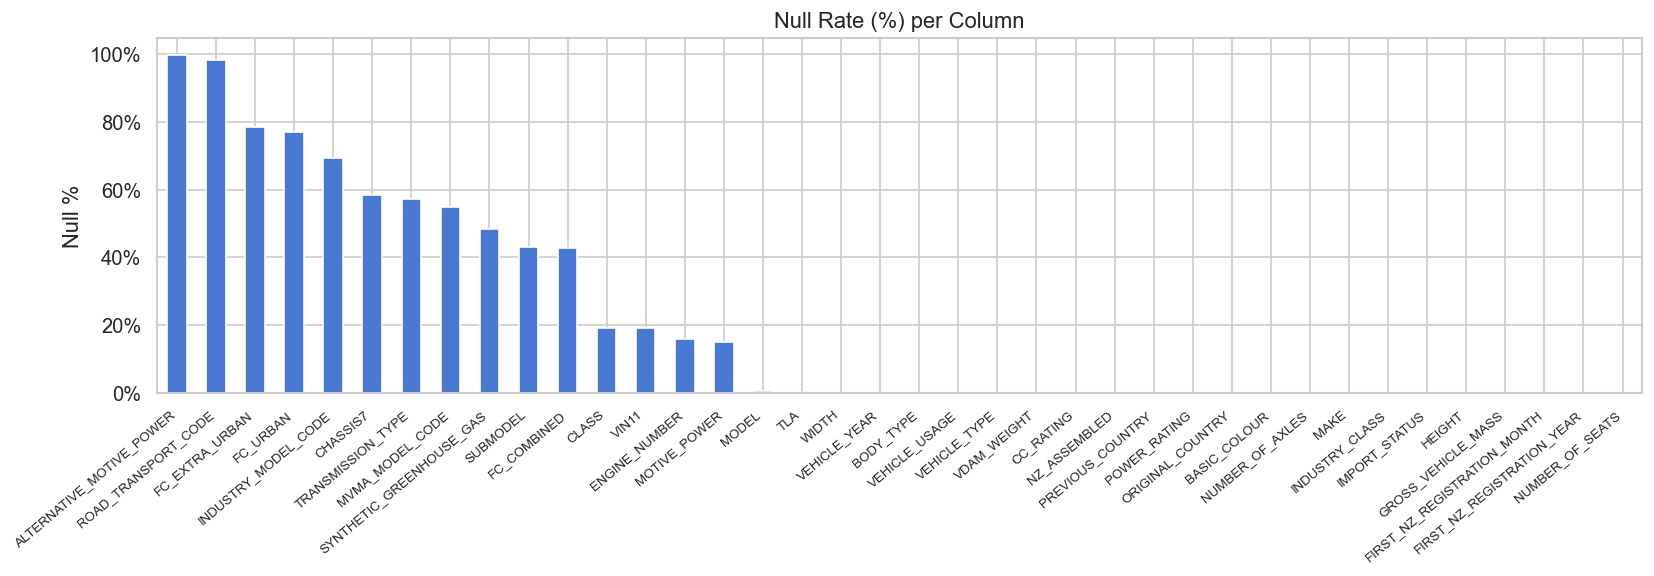

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
(
    quality_df
    .set_index("column")["null_rate_pct"]
    .sort_values(ascending=False)
    .plot.bar(ax=ax, color=sns.color_palette("muted")[0])
)
ax.set_title("Null Rate (%) per Column")
ax.set_ylabel("Null %")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)

Descriptive statistics on the numeric columns and overview of key categorical distributions.


In [9]:
numeric_cols = ["CC_RATING", "POWER_RATING", "GROSS_VEHICLE_MASS", "NUMBER_OF_SEATS",
                "VDAM_WEIGHT", "FC_COMBINED", "FC_URBAN", "FC_EXTRA_URBAN",
                "VEHICLE_YEAR", "FIRST_NZ_REGISTRATION_YEAR"]
present_numeric = [c for c in numeric_cols if c in df.columns]

df[present_numeric].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CC_RATING,5785322.0,2034.979337,1802.711562,0.0,1330.0,1990.0,2490.0,99999.0
POWER_RATING,5785322.0,58.241796,75.132944,0.0,0.0,0.0,115.0,999.0
GROSS_VEHICLE_MASS,5785322.0,2351.84722,4166.733156,0.0,1355.0,1810.0,2460.0,787627.0
NUMBER_OF_SEATS,5785322.0,4.092508,3.445559,0.0,3.0,5.0,5.0,999.0
VDAM_WEIGHT,5785322.0,837.244609,3844.746403,0.0,0.0,0.0,0.0,60800.0
FC_COMBINED,3330161.0,7.111064,2.141287,0.1,5.8,7.2,8.4,95.0
FC_URBAN,1341254.0,9.462158,2.774735,0.1,7.8,9.4,11.0,99.0
FC_EXTRA_URBAN,1259379.0,6.358223,1.35994,0.1,5.4,6.4,7.2,80.0
VEHICLE_YEAR,5785322.0,2008.914025,12.770752,0.0,2005.0,2011.0,2018.0,2025.0
FIRST_NZ_REGISTRATION_YEAR,5785123.0,2012.671208,11.293575,1899.0,2008.0,2016.0,2020.0,2025.0


In [ ]:
analyzer = DataAnalyzer(df)

fleet = analyzer.fleet_composition()
print("Fleet composition — top 10:")
print(fleet.head(10).to_string(index=False))

Fleet composition — top 10:
           vehicle_type   count
      PASSENGER CAR/VAN 3652684
GOODS VAN/TRUCK/UTILITY  909987
        TRAILER/CARAVAN  825994
             MOTORCYCLE  187021
          MOTOR CARAVAN   53300
                TRACTOR   45606
                    BUS   36617
                  MOPED   30405
         MOBILE MACHINE   26858
                    ATV    8918


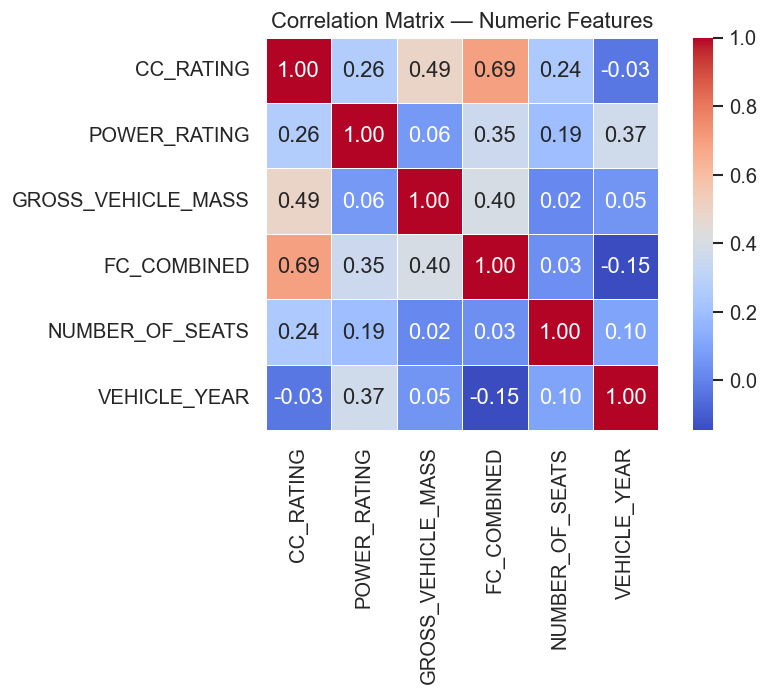

In [11]:
corr_cols = [c for c in ["CC_RATING", "POWER_RATING", "GROSS_VEHICLE_MASS",
                         "FC_COMBINED", "NUMBER_OF_SEATS", "VEHICLE_YEAR"]
             if c in df.columns]
corr = df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

## 5. Data Visualisation

A series of charts covering fleet composition, powertrain trends, EV adoption, imports, geography, and more.


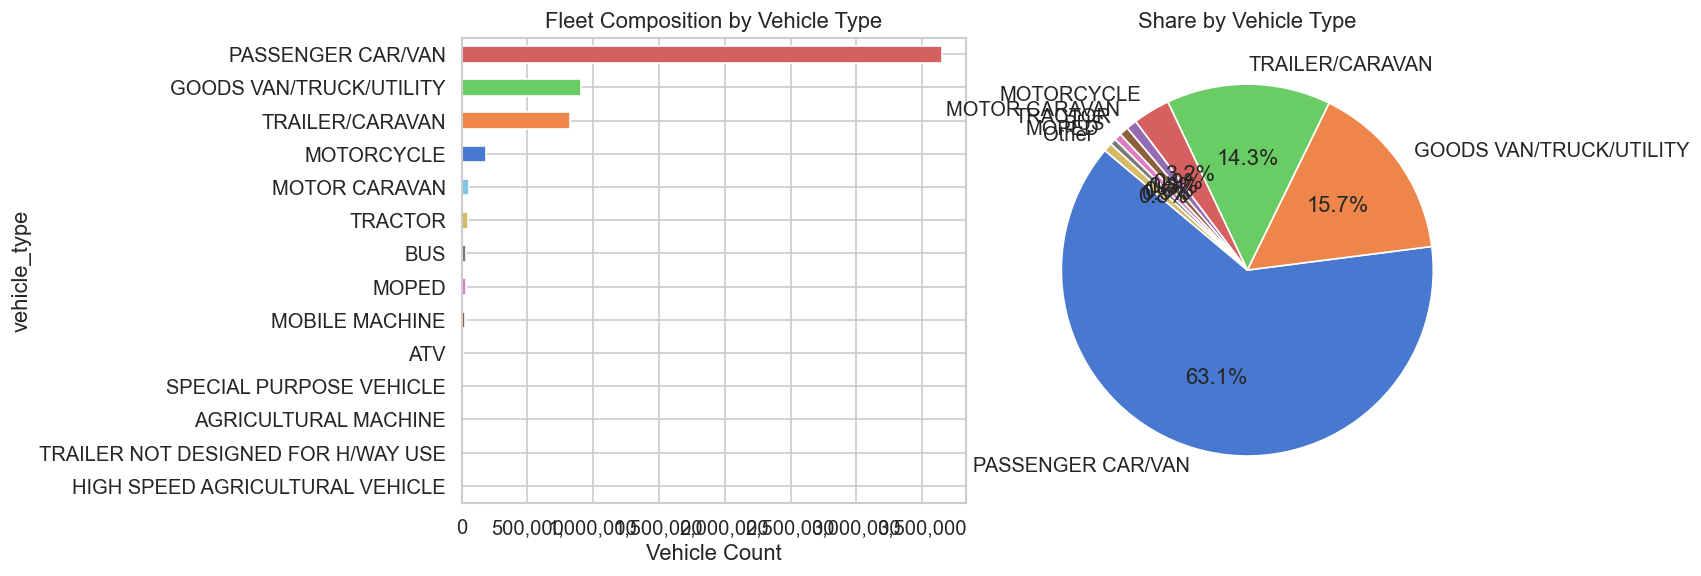

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fleet_plot = fleet.dropna(subset=["vehicle_type"]).set_index(
    "vehicle_type")["count"]

fleet_plot.sort_values().plot.barh(
    ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Fleet Composition by Vehicle Type")
axes[0].set_xlabel("Vehicle Count")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

top8 = fleet_plot.nlargest(8)
other = fleet_plot.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({"Other": other})])
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Share by Vehicle Type")

plt.tight_layout()
plt.show()

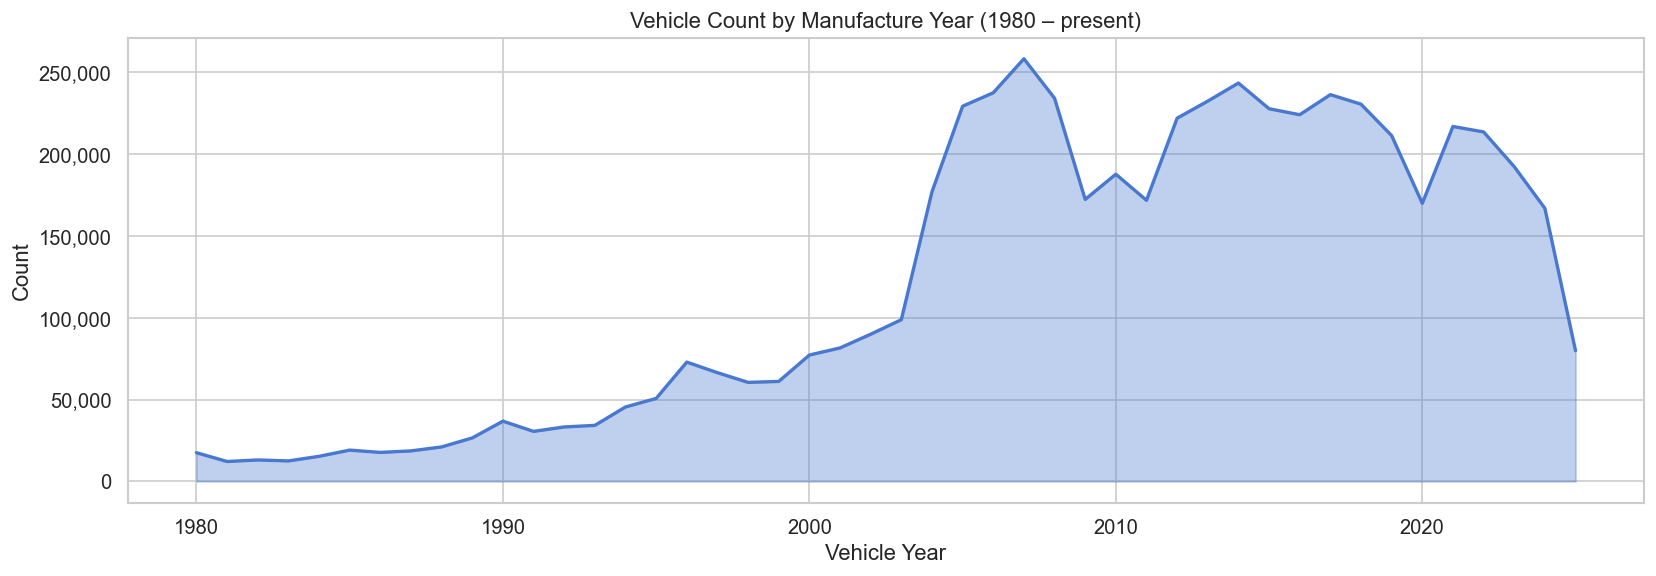

In [13]:
reg_by_year = analyzer.registrations_by_year()
reg_by_year["vehicle_year"] = pd.to_numeric(
    reg_by_year["vehicle_year"], errors="coerce")
reg_by_year = reg_by_year.dropna(subset=["vehicle_year"])
reg_by_year = reg_by_year[reg_by_year["vehicle_year"]
                          >= 1980].sort_values("vehicle_year")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(reg_by_year["vehicle_year"], reg_by_year["count"], alpha=0.35,
                color=sns.color_palette("muted")[0])
ax.plot(reg_by_year["vehicle_year"], reg_by_year["count"],
        color=sns.color_palette("muted")[0], linewidth=2)
ax.set_title("Vehicle Count by Manufacture Year (1980 – present)")
ax.set_xlabel("Vehicle Year")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

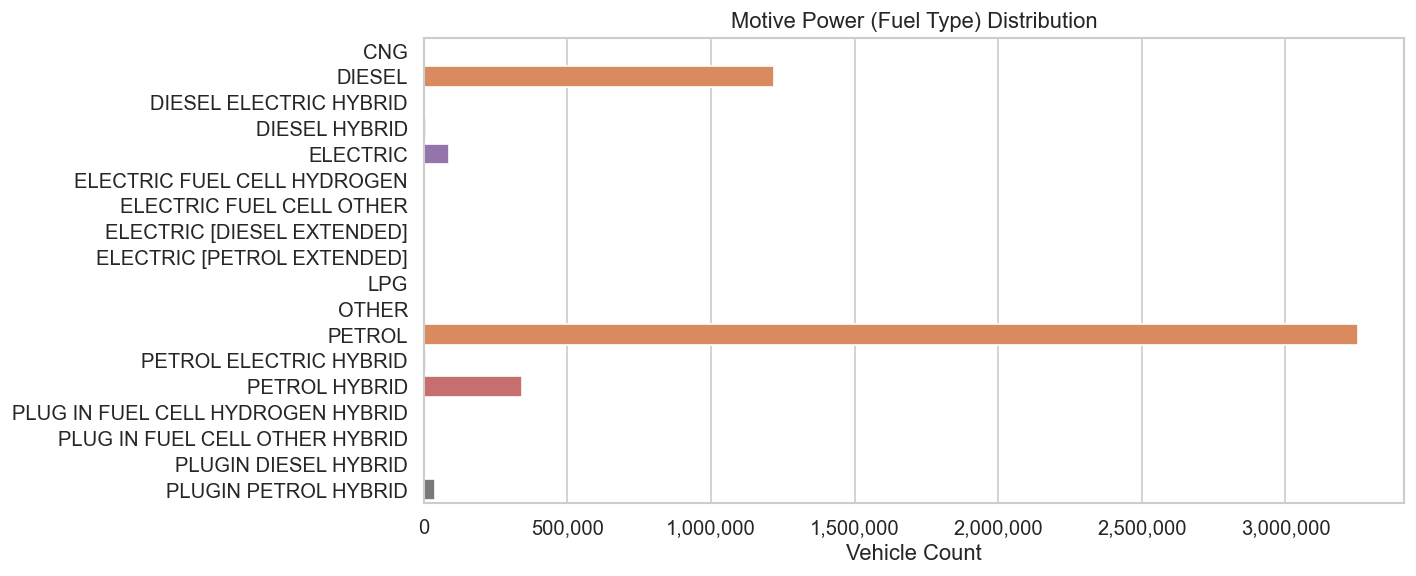

In [14]:
motive = analyzer.motive_power_distribution()
motive = motive.dropna(subset=["motive_power"])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=motive.head(12), y="motive_power", x="count", ax=ax,
            palette="muted", orient="h")
ax.set_title("Motive Power (Fuel Type) Distribution")
ax.set_xlabel("Vehicle Count")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

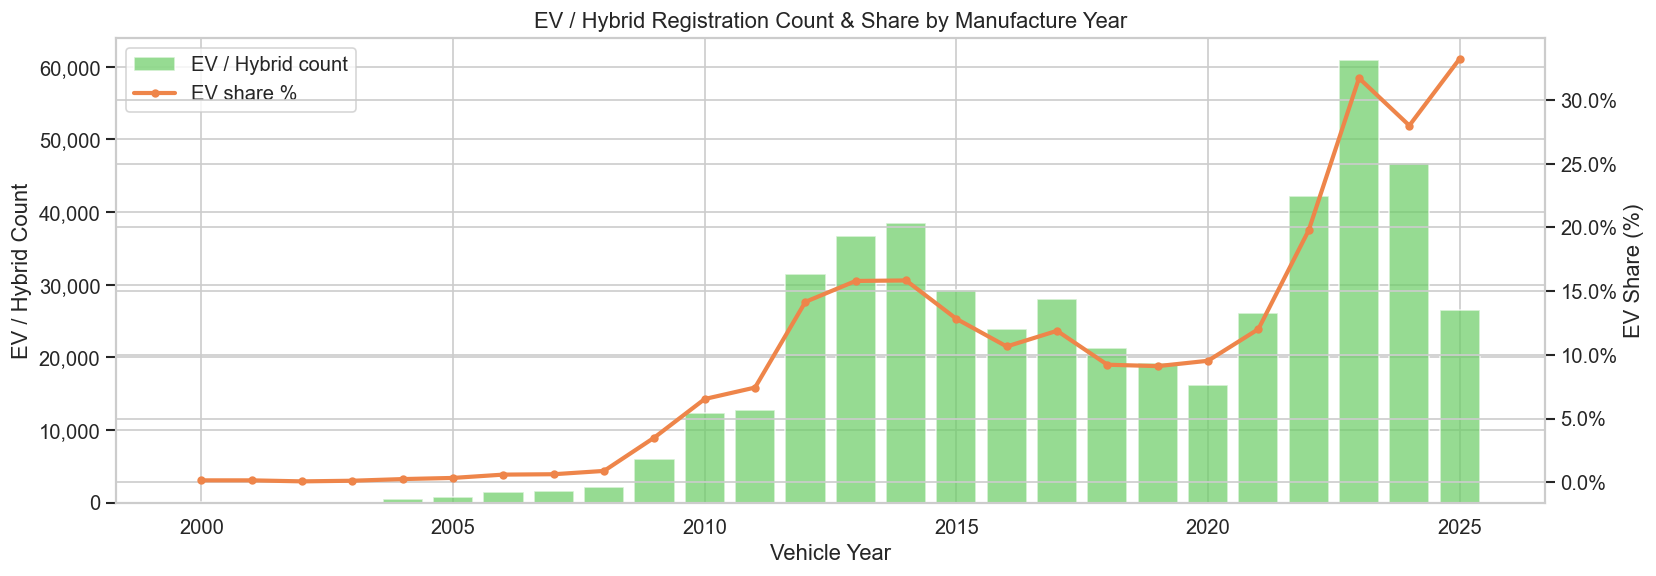

In [15]:
ev = analyzer.ev_adoption_by_year()
ev = ev[ev["vehicle_year"].between(2000, 2025)]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(ev["vehicle_year"], ev["ev_count"], color=sns.color_palette("muted")[2],
        alpha=0.7, label="EV / Hybrid count")
ax2.plot(ev["vehicle_year"], ev["ev_share_pct"], color=sns.color_palette("muted")[1],
         linewidth=2.5, marker="o", markersize=4, label="EV share %")

ax1.set_title("EV / Hybrid Registration Count & Share by Manufacture Year")
ax1.set_xlabel("Vehicle Year")
ax1.set_ylabel("EV / Hybrid Count")
ax2.set_ylabel("EV Share (%)")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

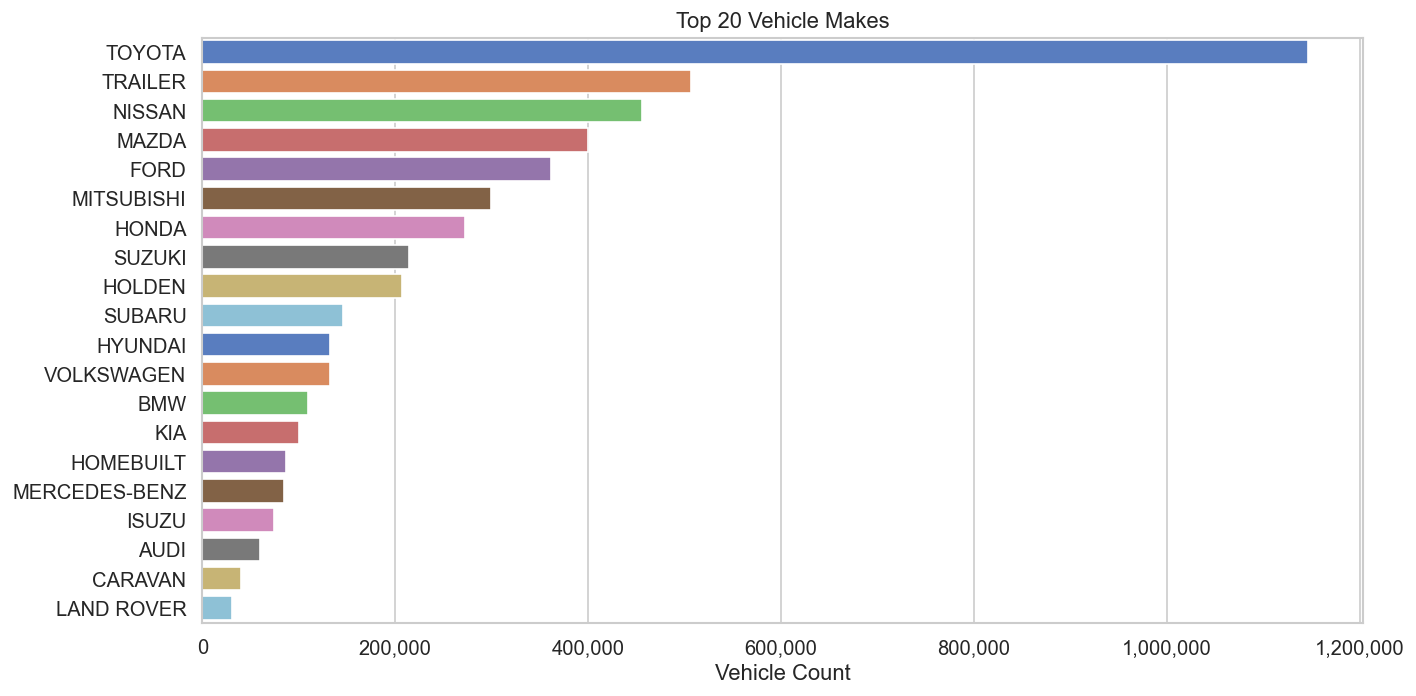

In [16]:
makes = analyzer.make_distribution(top_n=20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=makes, y="make", x="count",
            ax=ax, palette="muted", orient="h")
ax.set_title("Top 20 Vehicle Makes")
ax.set_xlabel("Vehicle Count")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

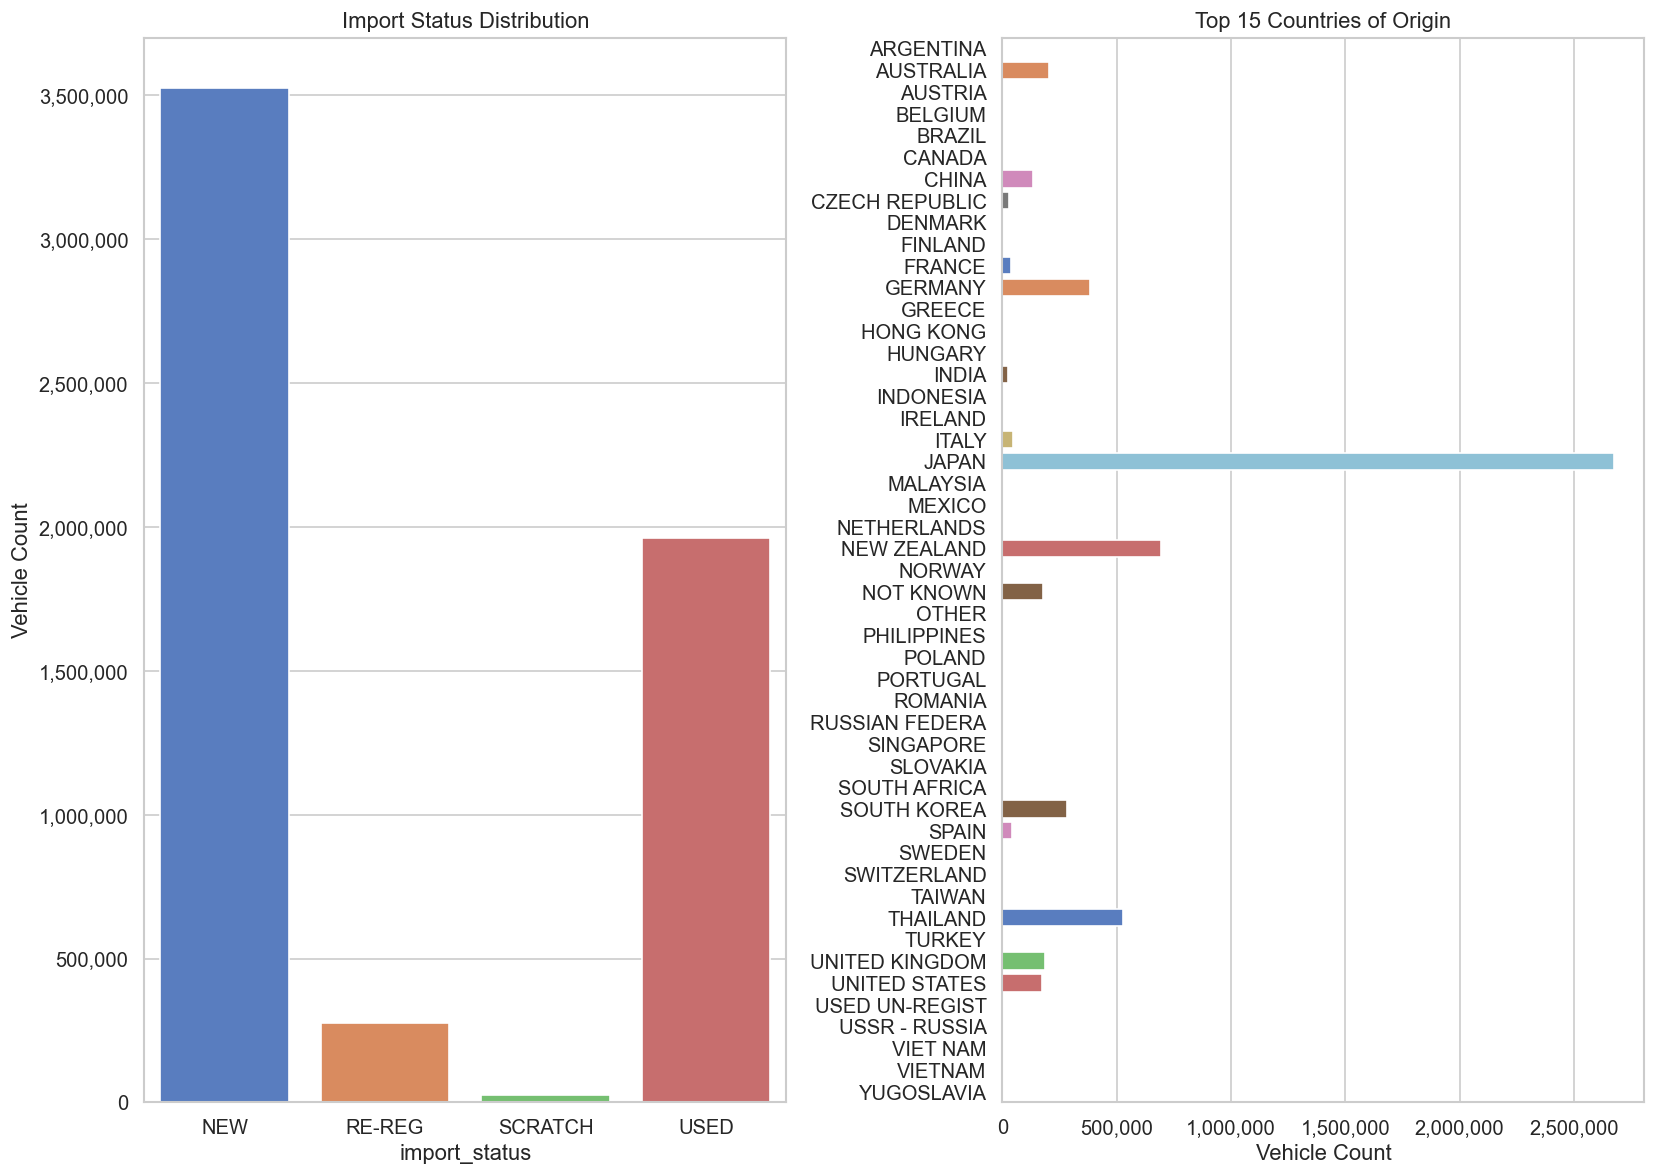

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

imp = analyzer.import_status_distribution().dropna(subset=["import_status"])
sns.barplot(data=imp, x="import_status",
            y="count", ax=axes[0], palette="muted")
axes[0].set_title("Import Status Distribution")
axes[0].set_ylabel("Vehicle Count")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

origin = analyzer.top_origin_countries(top_n=15)
sns.barplot(data=origin, y="country", x="count",
            ax=axes[1], palette="muted", orient="h")
axes[1].set_title("Top 15 Countries of Origin")
axes[1].set_xlabel("Vehicle Count")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

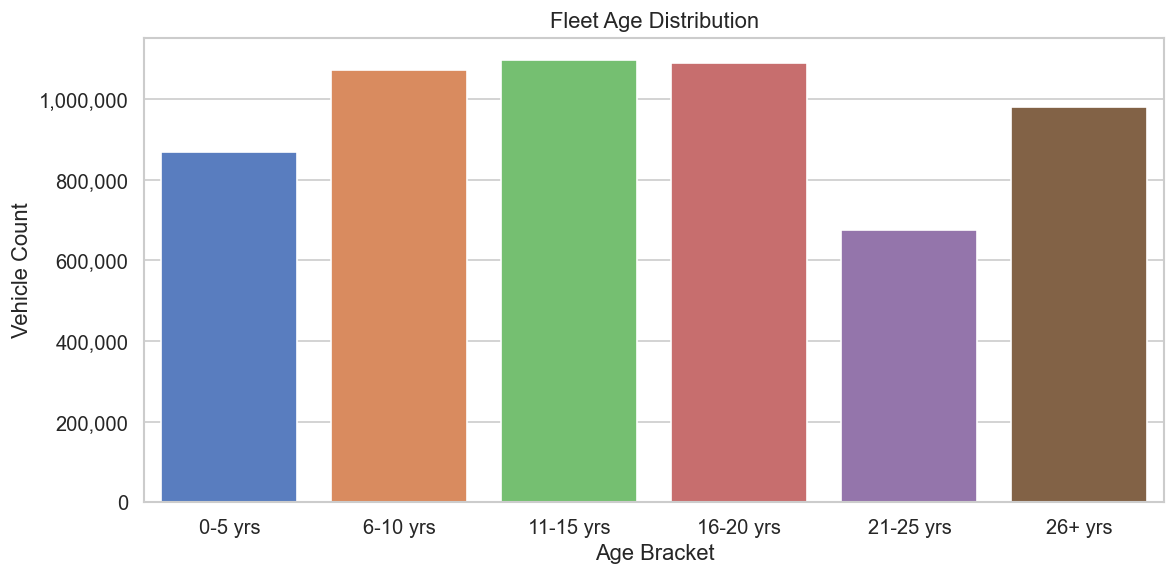

In [21]:
age_dist = analyzer.fleet_age_distribution()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=age_dist, x="age_bracket", y="count", ax=ax, palette="muted")
ax.set_title("Fleet Age Distribution")
ax.set_xlabel("Age Bracket")
ax.set_ylabel("Vehicle Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

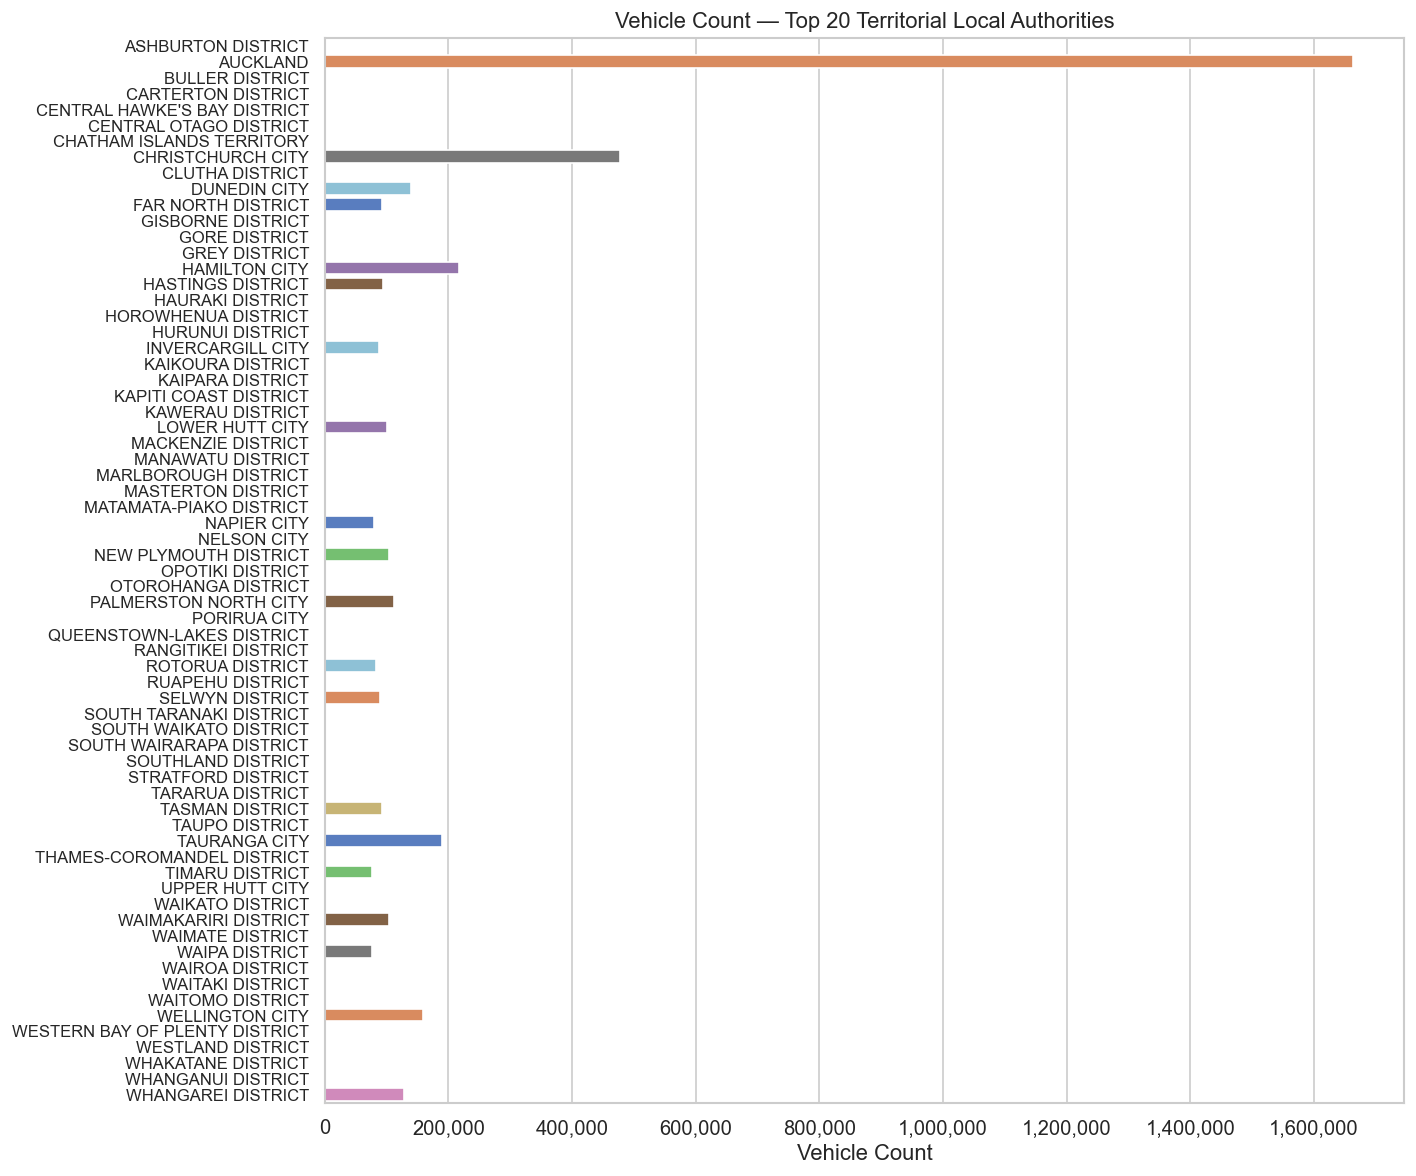

In [ ]:
geo = analyzer.geographic_distribution().dropna(subset=["tla"])

geo_top20 = geo.sort_values(by="count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(data=geo_top20, y="tla", x="count",
            ax=ax, palette="muted", orient="h")

ax.set_title("Vehicle Count — Top 20 Territorial Local Authorities")
ax.set_xlabel("Vehicle Count")
ax.set_ylabel("")

ax.tick_params(axis='y', labelsize=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

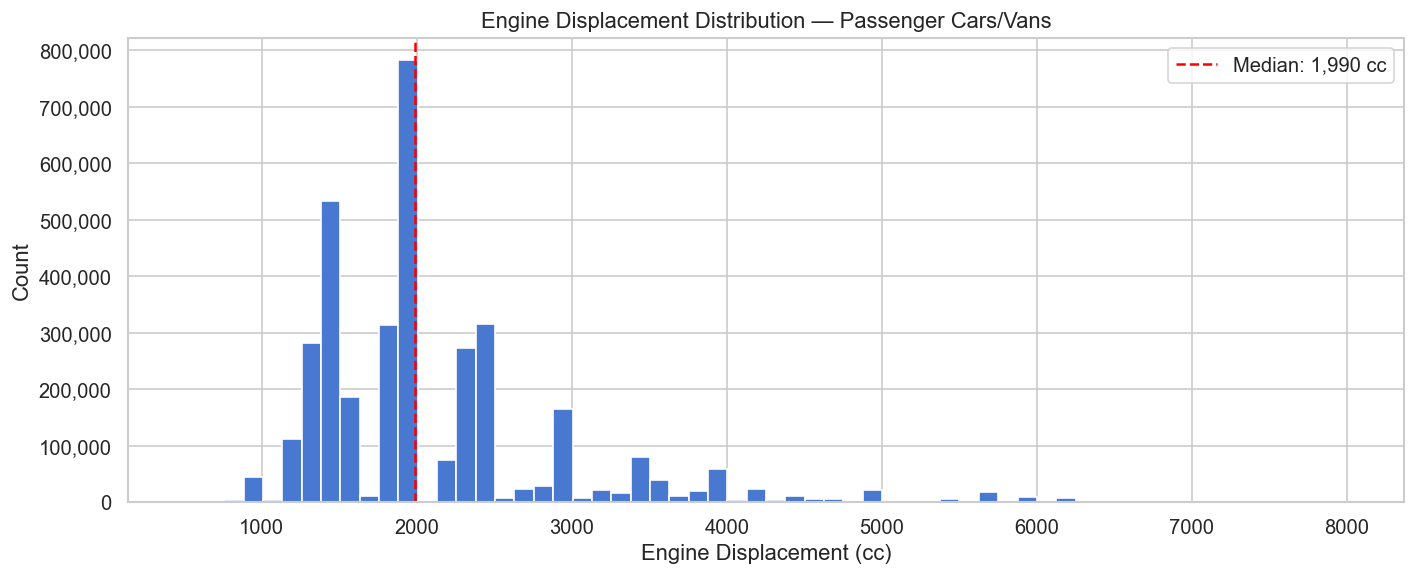

In [ ]:
if "CC_RATING" in df.columns and "VEHICLE_TYPE" in df.columns:
    cars_cc = (
        df[df["VEHICLE_TYPE"] == "PASSENGER CAR/VAN"]["CC_RATING"]
        .astype(float)
        .dropna()
    )
    cars_cc = cars_cc[(cars_cc > 500) & (cars_cc < 8000)]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(cars_cc, bins=60, color=sns.color_palette(
        "muted")[0], edgecolor="white")
    ax.axvline(cars_cc.median(), color="red", linestyle="--",
               label=f"Median: {cars_cc.median():,.0f} cc")
    ax.set_title("Engine Displacement Distribution — Passenger Cars/Vans")
    ax.set_xlabel("Engine Displacement (cc)")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Statistical Analysis

Regression between engine size and fuel consumption, vehicle usage breakdown, and fuel consumption by powertrain type.


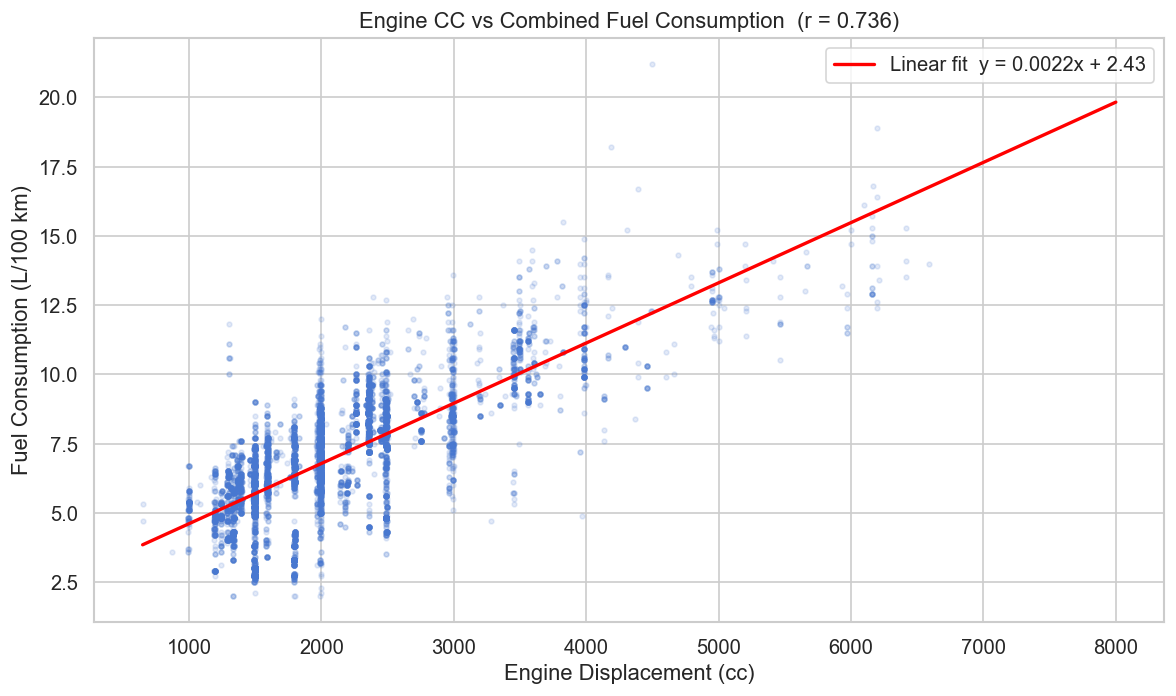

Pearson r = 0.736  (n = 2,702,844)


In [27]:
if {"CC_RATING", "FC_COMBINED", "VEHICLE_TYPE"}.issubset(df.columns):
    sample = (
        df[df["VEHICLE_TYPE"] == "PASSENGER CAR/VAN"][["CC_RATING", "FC_COMBINED"]]
        .astype(float)
        .dropna()
    )
    sample = sample[(sample["CC_RATING"].between(500, 8000)) &
                    (sample["FC_COMBINED"].between(2, 30))]
    plot_sample = sample.sample(min(10_000, len(sample)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(plot_sample["CC_RATING"], plot_sample["FC_COMBINED"],
               alpha=0.15, s=8, color=sns.color_palette("muted")[0])

    m, b = np.polyfit(sample["CC_RATING"], sample["FC_COMBINED"], 1)
    xs = np.linspace(sample["CC_RATING"].min(), sample["CC_RATING"].max(), 200)
    ax.plot(xs, m * xs + b, color="red", linewidth=2,
            label=f"Linear fit  y = {m:.4f}x + {b:.2f}")

    corr_val = sample.corr().loc["CC_RATING", "FC_COMBINED"]
    ax.set_title(
        f"Engine CC vs Combined Fuel Consumption  (r = {corr_val:.3f})")
    ax.set_xlabel("Engine Displacement (cc)")
    ax.set_ylabel("Fuel Consumption (L/100 km)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Pearson r = {corr_val:.3f}  (n = {len(sample):,})")

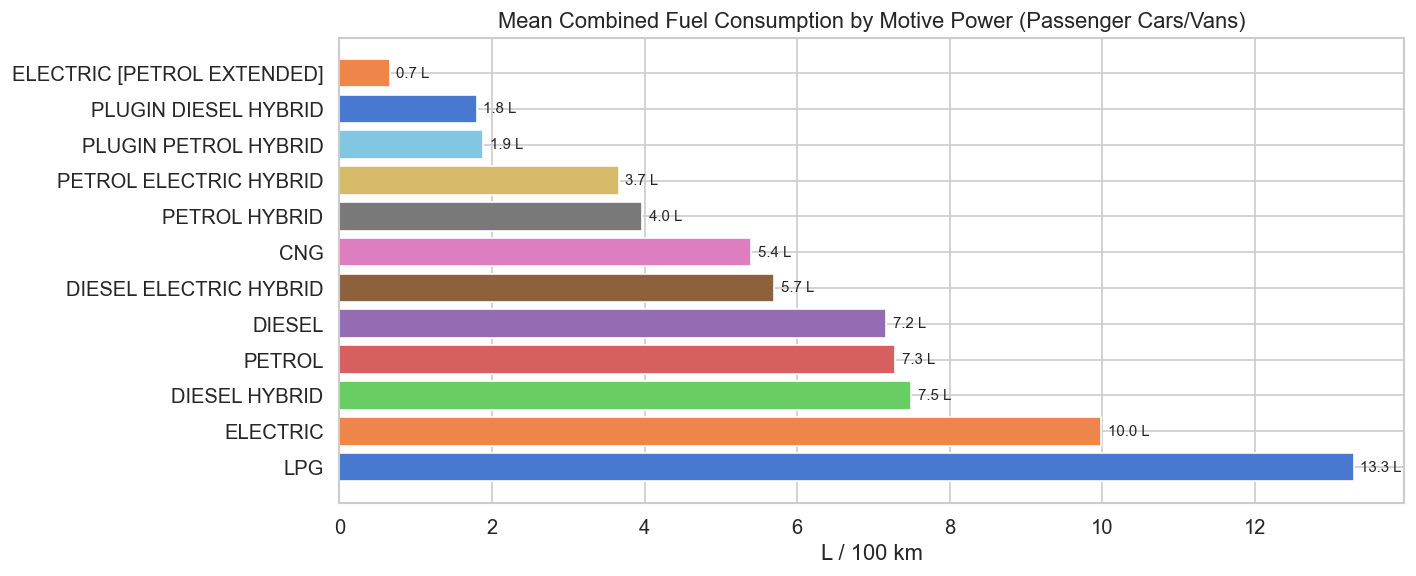

In [28]:
fc_stats = analyzer.fuel_consumption_stats()
if not fc_stats.empty and "MOTIVE_POWER" in fc_stats.columns:
    fc_plot = (
        fc_stats[fc_stats["VEHICLE_TYPE"] == "PASSENGER CAR/VAN"]
        .dropna(subset=["MOTIVE_POWER"])
        .sort_values("mean_l_per_100km", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(fc_plot["MOTIVE_POWER"], fc_plot["mean_l_per_100km"],
                   color=sns.color_palette("muted"))
    ax.bar_label(bars, labels=[f"{v:.1f} L" for v in fc_plot["mean_l_per_100km"]],
                 padding=4, fontsize=9)
    ax.set_title(
        "Mean Combined Fuel Consumption by Motive Power (Passenger Cars/Vans)")
    ax.set_xlabel("L / 100 km")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

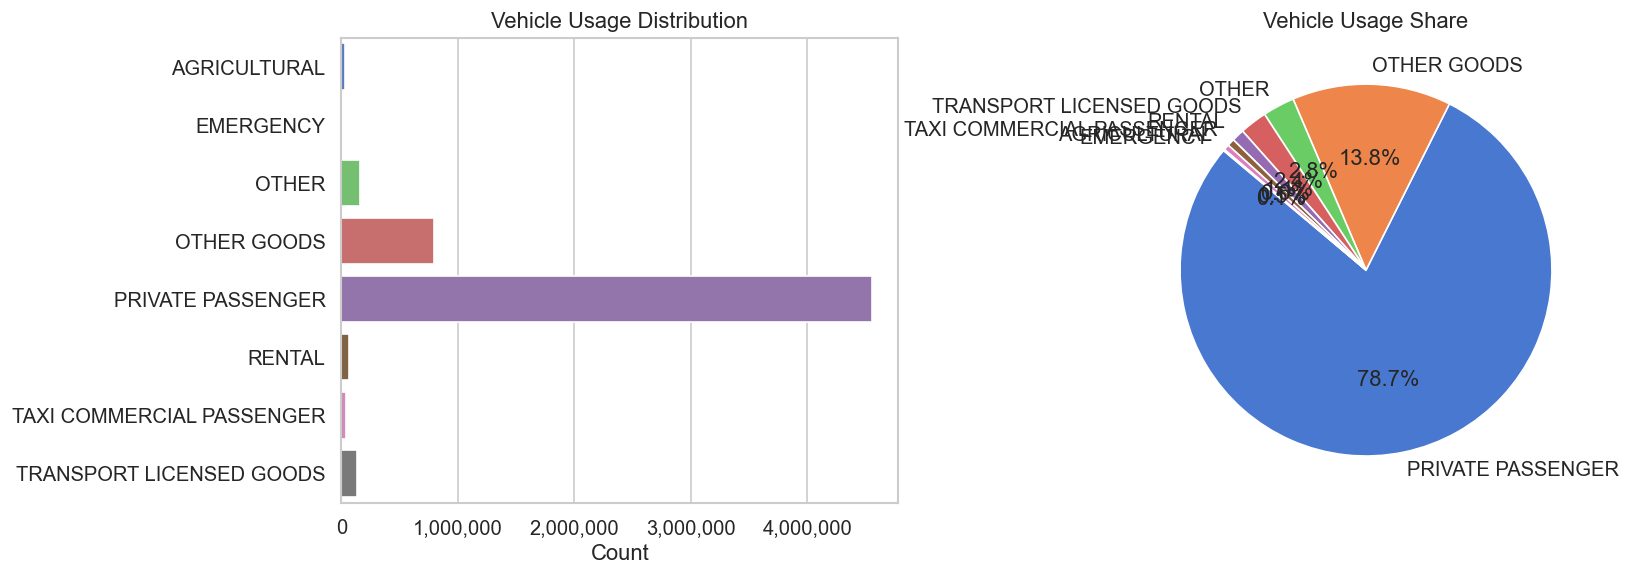

In [32]:
usage = analyzer.vehicle_usage_distribution().dropna(subset=["vehicle_usage"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=usage, y="vehicle_usage", x="count", ax=axes[0],
            palette="muted", orient="h")
axes[0].set_title("Vehicle Usage Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(usage["count"], labels=usage["vehicle_usage"],
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Vehicle Usage Share")

plt.tight_layout()
plt.show()

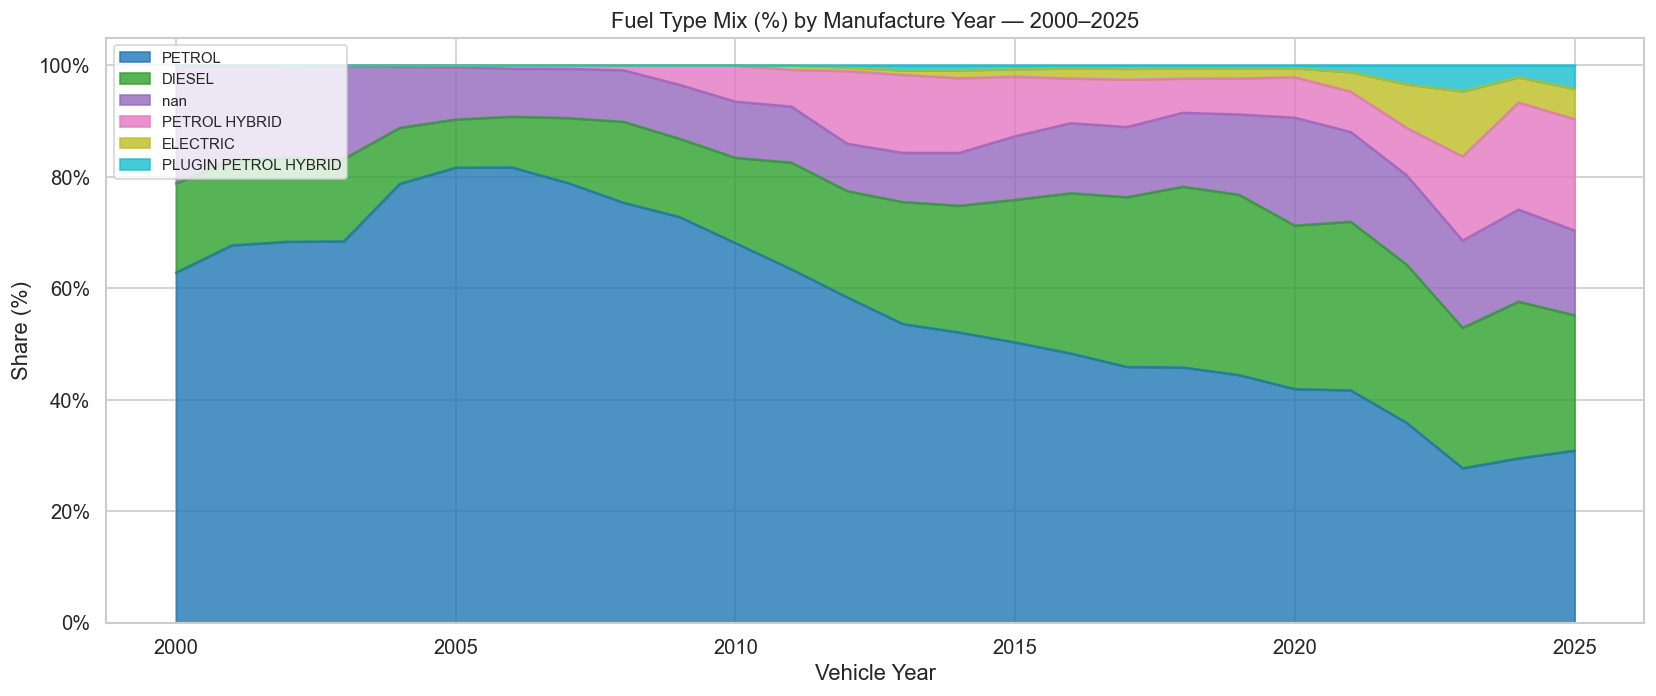

In [37]:
fuel_year = analyzer.fuel_type_by_year()
if not fuel_year.empty:
    fuel_year.index = pd.to_numeric(fuel_year.index, errors="coerce")

    # FIX: Use boolean masking instead of .between()
    mask = (fuel_year.index >= 2000) & (fuel_year.index <= 2025)
    fuel_year = fuel_year[mask].dropna()

    top_fuels = fuel_year.sum().nlargest(6).index
    fuel_plot = fuel_year[top_fuels]

    fuel_pct = fuel_plot.div(fuel_plot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    fuel_pct.plot.area(ax=ax, alpha=0.8, colormap="tab10")
    ax.set_title("Fuel Type Mix (%) by Manufacture Year — 2000–2025")
    ax.set_xlabel("Vehicle Year")
    ax.set_ylabel("Share (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

In [36]:
engine_stats = analyzer.engine_stats()
if not engine_stats.empty:
    engine_stats.columns = [" ".join(c).strip() for c in engine_stats.columns]
    display(engine_stats)

,CC_RATING count,CC_RATING mean,CC_RATING std,CC_RATING min,CC_RATING 25%,CC_RATING 50%,CC_RATING 75%,CC_RATING max,POWER_RATING count,POWER_RATING mean,POWER_RATING std,POWER_RATING min,POWER_RATING 25%,POWER_RATING 50%,POWER_RATING 75%,POWER_RATING max
VEHICLE_TYPE,,,,,,,,,,,,,,,,
AGRICULTURAL MACHINE,3315.0,6356.4,5536.5,0.0,3000.0,4500.0,8300.0,83000.0,3315.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATV,8918.0,639.6,626.4,0.0,400.0,567.0,875.0,39800.0,8918.0,0.4,18.4,0.0,0.0,0.0,0.0,999.0
BUS,36617.0,3826.3,2614.6,0.0,2499.0,2755.0,4000.0,90000.0,36617.0,50.1,56.0,0.0,0.0,0.0,100.0,430.0
GOODS VAN/TRUCK/UTILITY,909987.0,3552.0,2704.3,0.0,2442.0,2776.0,3198.0,98930.0,909987.0,98.6,71.9,0.0,0.0,122.0,147.0,895.0
HIGH SPEED AGRICULTURAL VEHICLE,235.0,6309.3,3366.7,130.0,6000.0,6600.0,6800.0,44245.0,235.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MOBILE MACHINE,26858.0,3471.8,3740.5,0.0,1995.0,2700.0,4300.0,99999.0,26858.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MOPED,30405.0,51.3,407.3,0.0,49.0,49.0,50.0,49000.0,30405.0,1.8,29.2,0.0,0.0,0.0,2.0,999.0
MOTOR CARAVAN,53300.0,3452.6,2363.9,0.0,2287.0,2500.0,3830.0,95000.0,53300.0,30.9,48.7,0.0,0.0,0.0,80.0,642.0
MOTORCYCLE,187021.0,808.2,777.3,0.0,398.0,750.0,1130.0,99801.0,187021.0,40.9,98.1,0.0,0.0,20.0,56.0,999.0
